In [2]:
import seaborn as sns
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import pandas as pd
import torch
import numpy as np
from plots import *

import h5py
sns.set_style("whitegrid")

# Font sizes
LABEL_FONTSIZE = 6
TICK_FONTSIZE = 6
LEGEND_FONTSIZE = 6

# Figure size
FIGSIZE = (3, 2)

# Line plot parameters
MARKERSIZE = 5
LINEWIDTH = 0.8
ALPHA = 1.0

# Spine and tick parameters
SPINE_WIDTH = 0.7
SPINE_COLOR = 'gray'
TICK_COLOR = 'gray'

# Grid parameters
GRID_ALPHA = 0.1
GRID_LINESTYLE = '--'
GRID_LINEWIDTH = 0.5
palette = plt.cm.tab10.colors

cell_colors = {
        'Immune': palette[0],
        'Str': palette[1],
        'Pod': palette[2],
        'CD': palette[3],
        'PE': palette[4],
        'Tcell': palette[5],
        'END': palette[6],  
        'DT': palette[7],
        'PT': palette[8],
        'LOH': palette[9]
    }

# Figure 5

In [ ]:
models=['borzoi_n_4k_n', 'borzoi_n_8k_n', 'borzoi_n_16k_n', 'borzoi_n_32k_n','borzoi_n_64k_n','borzoi_n_128k_n',  'borzoi_n_256k_n','borzoi_full']
cell_ids = ['Immune', 'Str', 'Pod', 'CD', 'PE', 'Tcell', 'END', 'DT', 'PT', 'LOH']
data_dir = "./arather/kidzoi/ubiquitous_peaks/"

results = {}
for model in models:
    
    pred_path = f"../../../train_data/ubiquitous_and_cell_specific_targets/kidzoi/with_ns/{model}/ubiquitous.pt"
    cells = ['Immune', 'stromal', 'Podocyte', 'CD', 'PE', 'Tcell', 'END', 'DT', 'PT', 'LOH']
    
    corrs_df = compute_cellwise_correlations_ubiquitous(
        data_dir=data_dir,
        predictions_path=pred_path,
        cells=cells,
        n_cell_ids=10,
        pred_slice=(4, 11)
    )
    corrs_df.columns = cells
    corrs_df.index = cells
    results[model] = corrs_df

ubiquitous_results_bor = {}
cell_ids = ['Immune', 'Str', 'Pod', 'CD', 'PE', 'Tcell', 'END', 'DT', 'PT', 'LOH']
for model in models:
    res = results[model]
    for i, cell in enumerate(cell_ids):
        ubiquitous_results_bor[f'{model}_{cell}' ] = res.iloc[i,i]

Immune - cell_0: Pearson r = 0.635
Immune - cell_1: Pearson r = 0.548
Immune - cell_2: Pearson r = 0.505
Immune - cell_3: Pearson r = 0.508
Immune - cell_4: Pearson r = 0.525
Immune - cell_5: Pearson r = 0.573
Immune - cell_6: Pearson r = 0.586
Immune - cell_7: Pearson r = 0.501
Immune - cell_8: Pearson r = 0.515
Immune - cell_9: Pearson r = 0.493
stromal - cell_0: Pearson r = 0.474
stromal - cell_1: Pearson r = 0.591
stromal - cell_2: Pearson r = 0.489
stromal - cell_3: Pearson r = 0.418
stromal - cell_4: Pearson r = 0.468
stromal - cell_5: Pearson r = 0.451
stromal - cell_6: Pearson r = 0.505
stromal - cell_7: Pearson r = 0.434
stromal - cell_8: Pearson r = 0.414
stromal - cell_9: Pearson r = 0.429
Podocyte - cell_0: Pearson r = 0.464
Podocyte - cell_1: Pearson r = 0.480
Podocyte - cell_2: Pearson r = 0.553
Podocyte - cell_3: Pearson r = 0.454
Podocyte - cell_4: Pearson r = 0.502
Podocyte - cell_5: Pearson r = 0.461
Podocyte - cell_6: Pearson r = 0.465
Podocyte - cell_7: Pearson r = 

In [19]:
data = {}
for key, value in ubiquitous_results_bor.items():

    model, cell = key.rsplit('_', 1)   # split from right
    
    if model not in data:
        data[model] = {}        
    data[model][cell] = value

def extract_length(model_name):
    
    if 'full' in model_name:
        return 'Full'
    
    return model_name.split('_')[2]   # extracts 4k, 8k etc

df = pd.DataFrame(data).T

df.index.name = 'Model'
df['Model'] = df.index.map(extract_length)
df_melted = df.reset_index(drop=True).melt(
    id_vars='Model',
    var_name='Cell Type',
    value_name='Performance'
)

sequence_order = ['4k', '8k', '16k', '32k', '64k', '128k', '256k', 'Full']

df_melted['Model'] = pd.Categorical(
    df_melted['Model'],
    categories=sequence_order,
    ordered=True
)

df_melted = df_melted.sort_values('Model')
df_melted['Model'] = df_melted['Model'].str.replace('k', 'kbp', regex=False)

In [20]:
df

,Immune,Str,Pod,CD,PE,Tcell,END,DT,PT,LOH,Model
Model,,,,,,,,,,,
borzoi_n_4k_n,0.634568,0.590731,0.553417,0.632932,0.482961,0.645788,0.602241,0.632532,0.612992,0.606938,4k
borzoi_n_8k_n,0.661776,0.616696,0.560095,0.638090,0.501450,0.681025,0.627268,0.642561,0.618998,0.609638,8k
borzoi_n_16k_n,0.703161,0.659544,0.578545,0.664726,0.535134,0.715333,0.657228,0.671481,0.641252,0.638663,16k
borzoi_n_32k_n,0.753385,0.697410,0.603749,0.705137,0.585705,0.755409,0.698370,0.712732,0.675302,0.681932,32k
borzoi_n_64k_n,0.790047,0.724356,0.625052,0.727163,0.633245,0.784717,0.731279,0.739240,0.709195,0.713180,64k
borzoi_n_128k_n,0.816529,0.751937,0.641737,0.744023,0.663869,0.803338,0.757558,0.753309,0.737172,0.730970,128k
borzoi_n_256k_n,0.832003,0.771768,0.655157,0.756688,0.691293,0.817543,0.778074,0.766212,0.759942,0.751429,256k
borzoi_full,0.836240,0.782160,0.665978,0.764724,0.702107,0.823280,0.785096,0.774879,0.769784,0.761247,Full


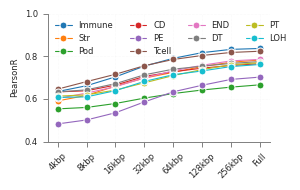

In [21]:
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=FIGSIZE)
palette = plt.cm.tab10.colors

sns.lineplot(
    data=df_melted,
    x='Model',
    y='Performance',
    hue='Cell Type',
    hue_order=list(cell_colors.keys()),
    marker='o',
    markersize=MARKERSIZE,
    linewidth=LINEWIDTH,
    alpha=ALPHA,
    palette=cell_colors,
    ax=ax
)

# Labels
ax.set_xlabel('')
ax.set_ylabel('PearsonR', fontsize=LABEL_FONTSIZE)

# Ticks
ax.tick_params(
    axis='both',
    which='major',
    labelsize=TICK_FONTSIZE,
    width=SPINE_WIDTH,
    color=TICK_COLOR,
    bottom=True,
    left=True,
    top=False,
    right=False
)
plt.xticks(rotation=45)

# Limits
ax.set_ylim(0.4, 1.0)
plt.yticks([0.4, 0.6, 0.8, 1.0])

# Legend
ax.legend(
    title='',
    fontsize=LEGEND_FONTSIZE,
    frameon=False,
    shadow=True,
    loc='upper left',
    ncol=4
)

# Spines
for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(SPINE_WIDTH)
    ax.spines[spine].set_color(SPINE_COLOR)

# Grid
ax.grid(
    True,
    alpha=GRID_ALPHA,
    linestyle=GRID_LINESTYLE,
    linewidth=GRID_LINEWIDTH
)

sns.despine(top=True, right=True, left=False, bottom=False)
plt.tight_layout()
#plt.savefig('./main_paper/fig5a_new.pdf', bbox_inches='tight')
plt.show()


# cell specific

In [ ]:
models=['borzoi_n_4k_n', 'borzoi_n_8k_n','borzoi_n_16k_n', 'borzoi_n_32k_n','borzoi_n_64k_n','borzoi_n_128k_n', 'borzoi_n_256k_n', 'borzoi_full']
cell_bed = ['Immune', 'Str', 'Pod', 'CD', 'PE', 'Tcell', 'END', 'DT', 'PT', 'LOH']
data_dir = "../../../train_data/ubiquitous_and_cell_specific_targets/kidzoi/cell_specific_bed/"
cells_bed = ['Immune', 'stromal', 'Podocyte', 'CD', 'PE', 'Tcell', 'END', 'DT', 'PT', 'LOH']

cells_pred = [
    'Immune_predictions',
    'stromal_predictions',
    'Podocyte_predictions',
    'CD_predictions',
    'PE_predictions',
    'Tcell_predictions',
    'END_predictions',
    'DT_predictions',
    'PT_predictions',
    'LOH_predictions'
]

results = {}

for model in models:
    
    pred_dir = f"../../../train_data/ubiquitous_and_cell_specific_targets/Borzoi_matched/with_ns/{model}/cell_specific"
    cells = ['Immune', 'stromal', 'Podocyte', 'CD', 'PE', 'Tcell', 'END', 'DT', 'PT', 'LOH']
    
    corrs_df = compute_cell_specific_correlations(
    target_dir = data_dir ,
    pred_dir= pred_dir,
    cells_bed=cells_bed, 
    cells_pred=cells_pred,
    n_cell_ids=10,
    pred_slice=(4, 11),
    model='borzoi'
    
    
)
    corrs_df.columns = cells
    corrs_df.index = cells
    results[model] = corrs_df

cell_specific_results = {}
cell_ids = ['Immune', 'Str', 'Pod', 'CD', 'PE', 'Tcell', 'END', 'DT', 'PT', 'LOH']
for model in models:
    res = results[model]
    for i, cell in enumerate(cell_ids):
        cell_specific_results[f'{model}_{cell}' ] = res.iloc[i,i]

Immune | cell_0: r = 0.308
Immune | cell_1: r = 0.055
Immune | cell_2: r = -0.140
Immune | cell_3: r = 0.031
Immune | cell_4: r = -0.022
Immune | cell_5: r = -0.035
Immune | cell_6: r = 0.080
Immune | cell_7: r = 0.063
Immune | cell_8: r = 0.038
Immune | cell_9: r = 0.074
stromal | cell_0: r = 0.029
stromal | cell_1: r = 0.321
stromal | cell_2: r = -0.041
stromal | cell_3: r = 0.061
stromal | cell_4: r = 0.005
stromal | cell_5: r = -0.005
stromal | cell_6: r = 0.051
stromal | cell_7: r = 0.069
stromal | cell_8: r = 0.015
stromal | cell_9: r = 0.065
Podocyte | cell_0: r = 0.020
Podocyte | cell_1: r = 0.059
Podocyte | cell_2: r = 0.365
Podocyte | cell_3: r = 0.068
Podocyte | cell_4: r = 0.128
Podocyte | cell_5: r = 0.031
Podocyte | cell_6: r = 0.004
Podocyte | cell_7: r = 0.056
Podocyte | cell_8: r = 0.057
Podocyte | cell_9: r = 0.086
CD | cell_0: r = 0.025
CD | cell_1: r = 0.091
CD | cell_2: r = -0.069
CD | cell_3: r = 0.440
CD | cell_4: r = -0.057
CD | cell_5: r = 0.028
CD | cell_6: r 

In [24]:
data = {}
for key, value in cell_specific_results.items():

    model, cell = key.rsplit('_', 1)   # split from right
    
    if model not in data:
        data[model] = {}
        
    data[model][cell] = value


def extract_length(model_name):
    
    if 'full' in model_name:
        return 'Full'
    
    return model_name.split('_')[2]   # extracts 4k, 8k etc

df = pd.DataFrame(data).T
df.index.name = 'Model'
df['Model'] = df.index.map(extract_length)
df_melted = df.reset_index(drop=True).melt(
    id_vars='Model',
    var_name='Cell Type',
    value_name='Performance'
)

df_melted['Model'] = pd.Categorical(
    df_melted['Model'],
    categories=sequence_order,
    ordered=True
)

df_melted = df_melted.sort_values('Model')

df_melted['Model'] = df_melted['Model'].str.replace('k', 'kbp', regex=False)

In [25]:
df

,Immune,Str,Pod,CD,PE,Tcell,END,DT,PT,LOH,Model
Model,,,,,,,,,,,
borzoi_n_4k_n,0.307876,0.321290,0.365323,0.440462,0.146782,0.123439,0.330296,0.358012,0.408293,0.419391,4k
borzoi_n_8k_n,0.316437,0.337241,0.363180,0.472233,0.161502,0.167658,0.351636,0.363415,0.407233,0.421904,8k
borzoi_n_16k_n,0.382917,0.375107,0.390106,0.538221,0.190455,0.259218,0.379823,0.382600,0.421843,0.446391,16k
borzoi_n_32k_n,0.468633,0.411078,0.427585,0.587911,0.224694,0.385162,0.417350,0.403366,0.460273,0.491950,32k
borzoi_n_64k_n,0.554419,0.451041,0.457266,0.607994,0.278377,0.477270,0.455940,0.425062,0.512330,0.520254,64k
borzoi_n_128k_n,0.620315,0.489287,0.480356,0.615569,0.327554,0.537563,0.508305,0.428505,0.557786,0.530087,128k
borzoi_n_256k_n,0.662042,0.511407,0.498711,0.622389,0.362527,0.577283,0.543703,0.430553,0.594483,0.542663,256k
borzoi_full,0.679447,0.528630,0.508801,0.624514,0.369759,0.595062,0.562511,0.437541,0.610560,0.557385,Full


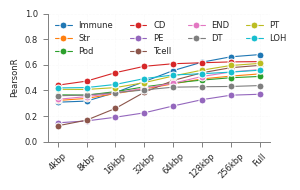

In [27]:

sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=FIGSIZE)

palette = plt.cm.tab10.colors

sns.lineplot(
    data=df_melted,
    x='Model',
    y='Performance',
    hue='Cell Type',
    hue_order=list(cell_colors.keys()),
    marker='o',
    markersize=MARKERSIZE,
    linewidth=LINEWIDTH,
    alpha=ALPHA,
    palette=cell_colors,
    ax=ax
)

# Labels
ax.set_xlabel('')
ax.set_ylabel('PearsonR', fontsize=LABEL_FONTSIZE)

# Ticks
ax.tick_params(
    axis='both',
    which='major',
    labelsize=TICK_FONTSIZE,
    width=SPINE_WIDTH,
    color=TICK_COLOR,
    bottom=True,
    left=True,
    top=False,
    right=False
)
plt.xticks(rotation=45)

# Limits
ax.set_ylim(0.0, 1.0)

# Legend
ax.legend(
    title='',
    fontsize=LEGEND_FONTSIZE,
    frameon=False,
    shadow=True,
    loc='upper left',
    ncol=4
)

# Spines
for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(SPINE_WIDTH)
    ax.spines[spine].set_color(SPINE_COLOR)

# Grid
ax.grid(
    True,
    alpha=GRID_ALPHA,
    linestyle=GRID_LINESTYLE,
    linewidth=GRID_LINEWIDTH
)

# Clean up
sns.despine(top=True, right=True, left=False, bottom=False)

plt.tight_layout()
plt.savefig('./fig5b.pdf', bbox_inches='tight')
plt.show()


## Analysis with allelic imbalance

In [36]:
values = [4]
cells = {
    "DT": 7,
    "PT": 8,
    "LOH": 9
}

all_results ={}
ns_after_list = ["inser_ns_after_4k_rep0", "inser_ns_after_8k_rep0", "inser_ns_after_16k_rep0", "inser_ns_after_32k_rep0", "inser_ns_after_64k_rep0", 'inser_ns_after_128k_rep0', 'inser_ns_after_256k_rep0', 'rep0_all_bins_no_shifts']



for cell_name, cell_id in cells.items():
    all_results[cell_name] = {} 
    for ns_after in ns_after_list:

        print(f"Running for cell={cell_name}, cell_id={cell_id}, ns_after={ns_after}")

        pos_path = f"../caai_results/borzoi_finetuned_scoring/{ns_after}/{cell_name}/pos/sad.h5"
        neg_path = f"../caai_results/borzoi_finetuned_scoring/{ns_after}/{cell_name}/neg/sad.h5"

        pos_sad = h5py.File(pos_path, "r")
        neg_sad = h5py.File(neg_path, "r")

        

        results = sliding_sad_metrics(
            pos_sad,
            neg_sad,
            seqlen=16384,
            cell_id=cell_id,
            values=values
        )
        all_results[cell_name][ns_after] = results

        pos_sad.close()
        neg_sad.close()

        print(f"Finished: {cell_name}, ns_after={ns_after}")


Running for cell=DT, cell_id=7, ns_after=inser_ns_after_4k_rep0


/tmp/ipykernel_94408/2131777395.py:193: RuntimeWarning: invalid value encountered in divide
  neg_caai = neg_ref / (neg_ref + neg_alt + eps)


Finished: DT, ns_after=inser_ns_after_4k_rep0
Running for cell=DT, cell_id=7, ns_after=inser_ns_after_8k_rep0
Finished: DT, ns_after=inser_ns_after_8k_rep0
Running for cell=DT, cell_id=7, ns_after=inser_ns_after_16k_rep0
Finished: DT, ns_after=inser_ns_after_16k_rep0
Running for cell=DT, cell_id=7, ns_after=inser_ns_after_32k_rep0
Finished: DT, ns_after=inser_ns_after_32k_rep0
Running for cell=DT, cell_id=7, ns_after=inser_ns_after_64k_rep0
Finished: DT, ns_after=inser_ns_after_64k_rep0
Running for cell=DT, cell_id=7, ns_after=inser_ns_after_128k_rep0
Finished: DT, ns_after=inser_ns_after_128k_rep0
Running for cell=DT, cell_id=7, ns_after=inser_ns_after_256k_rep0
Finished: DT, ns_after=inser_ns_after_256k_rep0
Running for cell=DT, cell_id=7, ns_after=rep0_all_bins_no_shifts
Finished: DT, ns_after=rep0_all_bins_no_shifts
Running for cell=PT, cell_id=8, ns_after=inser_ns_after_4k_rep0
Finished: PT, ns_after=inser_ns_after_4k_rep0
Running for cell=PT, cell_id=8, ns_after=inser_ns_after_8k

/tmp/ipykernel_94408/2131777395.py:193: RuntimeWarning: invalid value encountered in divide
  neg_caai = neg_ref / (neg_ref + neg_alt + eps)


Finished: LOH, ns_after=inser_ns_after_4k_rep0
Running for cell=LOH, cell_id=9, ns_after=inser_ns_after_8k_rep0
Finished: LOH, ns_after=inser_ns_after_8k_rep0
Running for cell=LOH, cell_id=9, ns_after=inser_ns_after_16k_rep0
Finished: LOH, ns_after=inser_ns_after_16k_rep0
Running for cell=LOH, cell_id=9, ns_after=inser_ns_after_32k_rep0
Finished: LOH, ns_after=inser_ns_after_32k_rep0
Running for cell=LOH, cell_id=9, ns_after=inser_ns_after_64k_rep0
Finished: LOH, ns_after=inser_ns_after_64k_rep0
Running for cell=LOH, cell_id=9, ns_after=inser_ns_after_128k_rep0
Finished: LOH, ns_after=inser_ns_after_128k_rep0
Running for cell=LOH, cell_id=9, ns_after=inser_ns_after_256k_rep0
Finished: LOH, ns_after=inser_ns_after_256k_rep0
Running for cell=LOH, cell_id=9, ns_after=rep0_all_bins_no_shifts
Finished: LOH, ns_after=rep0_all_bins_no_shifts


In [37]:
SEQUENCE_ORDER = ['4kbp', '8kbp', '16kbp', '32kbp', '64kbp', '128kbp','256kbp', 'full']
ns_mapping = {
    "inser_ns_after_4k_rep0": "4kbp",
    "inser_ns_after_8k_rep0": "8kbp",
    "inser_ns_after_16k_rep0": "16kbp",
    "inser_ns_after_32k_rep0": "32kbp",
    "inser_ns_after_64k_rep0": "64kbp",
    "inser_ns_after_128k_rep0": "128kbp",
    "inser_ns_after_256k_rep0": "256kbp",
    "rep0_all_bins_no_shifts": "full"
}

# Build data dictionary
data = {seq: [] for seq in SEQUENCE_ORDER}

for ns_after, seq_label in ns_mapping.items():
    dt_val  = all_results['DT'][ns_after]['auroc'][0]
    pt_val  = all_results['PT'][ns_after]['auroc'][0]
    loh_val = all_results['LOH'][ns_after]['auroc'][0]

    data[seq_label] = [float(dt_val), float(pt_val), float(loh_val)]

# Create dataframe
df = pd.DataFrame(data, index=['DT', 'PT', 'LOH']).T
df.index.name = 'Model'

# Melt for plotting
df_melted = df.reset_index().melt(
    id_vars='Model',
    var_name='Type',
    value_name='AUROC'
)

df_melted['Model'] = pd.Categorical(
    df_melted['Model'],
    categories=SEQUENCE_ORDER,
    ordered=True
)



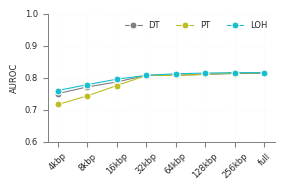

In [58]:
fig, ax = plt.subplots(figsize=FIGSIZE)

sns.lineplot(
    data=df_melted, x='Model', y='AUROC', hue='Type',
    marker='o', markersize=MARKERSIZE, linewidth=LINEWIDTH,
    palette=PALETTE, ax=ax, alpha=ALPHA
)

ax.set_xlabel('')

ax.set_ylabel('AUROC', fontsize=LABEL_FONTSIZE)
ax.set_ylim(0.6, 1.0)

plt.xticks(rotation=45)
#plt.yticks([0.6, 0.65, 0.7, 0.75, 0.8, 0.85])
plt.legend(title='', title_fontsize=LEGEND_FONTSIZE, fontsize=LEGEND_FONTSIZE,
           frameon=False, shadow=True, loc='upper right', ncol=3)

ax.spines['left'].set_linewidth(SPINE_WIDTH)
ax.spines['left'].set_color(SPINE_COLOR)
ax.spines['bottom'].set_linewidth(SPINE_WIDTH)
ax.spines['bottom'].set_color(SPINE_COLOR)

ax.tick_params(axis='both', which='major', labelsize=TICK_FONTSIZE,
               bottom=True, left=True, top=False, right=False, color=TICK_COLOR)

ax.grid(True, alpha=GRID_ALPHA, linestyle=GRID_LINESTYLE, linewidth=GRID_LINEWIDTH)

sns.despine(top=True, right=True, left=False, bottom=False)

plt.tight_layout()
plt.savefig('main_paper/fig5c.pdf', bbox_inches='tight')
plt.show()

In [42]:
# Build data dictionary
data = {seq: [] for seq in SEQUENCE_ORDER}

for ns_after, seq_label in ns_mapping.items():
    dt_val  = all_results['DT'][ns_after]['auprc'][0]
    pt_val  = all_results['PT'][ns_after]['auprc'][0]
    loh_val = all_results['LOH'][ns_after]['auprc'][0]

    data[seq_label] = [float(dt_val), float(pt_val), float(loh_val)]

# Create dataframe
df = pd.DataFrame(data, index=['DT', 'PT', 'LOH']).T
df.index.name = 'Model'

# Melt for plotting
df_melted = df.reset_index().melt(
    id_vars='Model',
    var_name='Type',
    value_name='AUPRC'
)

df_melted['Model'] = pd.Categorical(
    df_melted['Model'],
    categories=SEQUENCE_ORDER,
    ordered=True
)



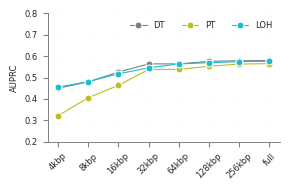

In [56]:
fig, ax = plt.subplots(figsize=FIGSIZE)

sns.lineplot(
    data=df_melted, x='Model', y='AUROC', hue='Type',
    marker='o', markersize=MARKERSIZE, linewidth=LINEWIDTH,
    palette=PALETTE, ax=ax, alpha=ALPHA
)

ax.set_xlabel('')

ax.set_ylabel('AUPRC', fontsize=LABEL_FONTSIZE)
ax.set_ylim(0.2, 0.8)

plt.xticks(rotation=45)
#plt.yticks([0.6, 0.65, 0.7, 0.75, 0.8, 0.85])
plt.legend(title='', title_fontsize=LEGEND_FONTSIZE, fontsize=LEGEND_FONTSIZE,
           frameon=False, shadow=True, loc='upper right', ncol=3)

ax.spines['left'].set_linewidth(SPINE_WIDTH)
ax.spines['left'].set_color(SPINE_COLOR)
ax.spines['bottom'].set_linewidth(SPINE_WIDTH)
ax.spines['bottom'].set_color(SPINE_COLOR)

ax.tick_params(axis='both', which='major', labelsize=TICK_FONTSIZE,
               bottom=True, left=True, top=False, right=False, color=TICK_COLOR)

ax.grid(True, alpha=GRID_ALPHA, linestyle=GRID_LINESTYLE, linewidth=GRID_LINEWIDTH)

sns.despine(top=True, right=True, left=False, bottom=False)

plt.tight_layout()
plt.savefig('main_paper/fig5d.pdf',dpi = 600, bbox_inches='tight')
plt.show()

# analysis with finemapping

In [ ]:
borzoi_score_dir = "/home/ch263720/Public/arather/kidformer/notes/caai_results/fine_mapped/kidzoi/"

In [77]:
values= [32]
cells= {
    'immune': 0,
    'str': 1,
    'pod': 2,
    'CD': 3,
    'PE': 4,
    'tcell': 5,
    'end': 6,
    'dt': 7,
    'pt': 8,
    'loh': 9
}

ns_after_list = ["insert_ns_after_4k", "insert_ns_after_8k", "insert_ns_after_16k", "insert_ns_after_32k", "insert_ns_after_64k",'insert_ns_after_128k','insert_ns_after_256k','full']
all_results = {} 

for cell_name, cell_id in cells.items():
    all_results[cell_name] = {} 
    for ns_after in ns_after_list:

        print(f"Running for cell={cell_name}, cell_id={cell_id}, ns_after={ns_after}")

        pos_path = f"{borzoi_score_dir}/with_ns_new/pos/{ns_after}/sad.h5"
        neg_path = f"{borzoi_score_dir}/with_ns_new/neg/{ns_after}/sad.h5"

        pos_sad = h5py.File(pos_path, "r")
        neg_sad = h5py.File(neg_path, "r")

        seq_len = neg_sad['REF'].shape[1]

        
        results = compute_sad_metrics(
                            pos_sad,
                            neg_sad,
                            pos_index,
                            cell_id,
                            values
                        )

        all_results[cell_name][ns_after] = results

        
        print(f"Finished: {cell_name}, ns_after={ns_after}")


Running for cell=immune, cell_id=0, ns_after=insert_ns_after_4k
Finished: immune, ns_after=insert_ns_after_4k
Running for cell=immune, cell_id=0, ns_after=insert_ns_after_8k
Finished: immune, ns_after=insert_ns_after_8k
Running for cell=immune, cell_id=0, ns_after=insert_ns_after_16k
Finished: immune, ns_after=insert_ns_after_16k
Running for cell=immune, cell_id=0, ns_after=insert_ns_after_32k
Finished: immune, ns_after=insert_ns_after_32k
Running for cell=immune, cell_id=0, ns_after=insert_ns_after_64k
Finished: immune, ns_after=insert_ns_after_64k
Running for cell=immune, cell_id=0, ns_after=insert_ns_after_128k
Finished: immune, ns_after=insert_ns_after_128k
Running for cell=immune, cell_id=0, ns_after=insert_ns_after_256k
Finished: immune, ns_after=insert_ns_after_256k
Running for cell=immune, cell_id=0, ns_after=full
Finished: immune, ns_after=full
Running for cell=str, cell_id=1, ns_after=insert_ns_after_4k
Finished: str, ns_after=insert_ns_after_4k
Running for cell=str, cell_id=

In [129]:
rows = []
for cell_type, models in all_results.items():
    for model, metrics in models.items():
        rows.append({
            "Cell": cell_type,
            "Model": model,
            "Num": metrics["num"][0],
            "AUROC": metrics["auroc"][0],
            "AUPRC": metrics["auprc"][0]
        })

df = pd.DataFrame(rows)
df

,Cell,Model,Num,AUROC,AUPRC
0,immune,insert_ns_after_4k,32,0.610846,0.283947
1,immune,insert_ns_after_8k,32,0.627237,0.289840
2,immune,insert_ns_after_16k,32,0.654755,0.316533
3,immune,insert_ns_after_32k,32,0.683955,0.339573
4,immune,insert_ns_after_64k,32,0.706380,0.342494
...,...,...,...,...,...
75,loh,insert_ns_after_32k,32,0.756884,0.465408
76,loh,insert_ns_after_64k,32,0.773539,0.466639
77,loh,insert_ns_after_128k,32,0.772049,0.459526
78,loh,insert_ns_after_256k,32,0.786706,0.464306


In [13]:
# Desired order
model_order = [
    'insert_ns_after_4k',
    'insert_ns_after_8k',
    'insert_ns_after_16k',
    'insert_ns_after_32k',
    'insert_ns_after_64k',
    'insert_ns_after_128k',
    'insert_ns_after_256k',
    'full'
]

cell_order = [
    'immune', 'str', 'pod', 'CD', 'PE',
    'tcell', 'end', 'dt', 'pt', 'loh'
]

model_map = {
    'insert_ns_after_4k': '4k',
    'insert_ns_after_8k': '8k',
    'insert_ns_after_16k': '16k',
    'insert_ns_after_32k': '32k',
    'insert_ns_after_64k': '64k',
    'insert_ns_after_128k': '128k',
    'insert_ns_after_256k': '256k',
    'full': 'Full'
}

df_auroc = (
    df.pivot(index='Model', columns='Cell', values='AUROC')
      .reindex(model_order)          # Keep rows in desired order
      .reindex(columns=cell_order)   # Keep columns in desired order
      .rename(columns={
          'immune': 'Immune',
          'str': 'Str',
          'pod': 'Pod',
          'CD': 'CD',
          'PE': 'PE',
          'tcell': 'Tcell',
          'end': 'END',
          'dt': 'DT',
          'pt': 'PT',
          'loh': 'LOH'
      })
      .reset_index()
)

df_auroc['Context'] = df_auroc['Model'].map(model_map)
df_auroc

Cell,Model,Immune,Str,Pod,CD,PE,Tcell,END,DT,PT,LOH,Context
0,insert_ns_after_4k,0.610846,0.686317,0.678076,0.677424,0.711039,0.630120,0.637890,0.709852,0.682035,0.688147,4k
1,insert_ns_after_8k,0.627237,0.708851,0.680435,0.701255,0.730993,0.653771,0.659251,0.718496,0.705137,0.711640,8k
2,insert_ns_after_16k,0.654755,0.720293,0.712812,0.724690,0.745438,0.669881,0.678522,0.737389,0.707435,0.738431,16k
3,insert_ns_after_32k,0.683955,0.739337,0.728784,0.749335,0.760749,0.686833,0.705185,0.758039,0.745591,0.756884,32k
4,insert_ns_after_64k,0.706380,0.762666,0.744450,0.762499,0.774032,0.693895,0.731227,0.767488,0.760340,0.773539,64k
5,insert_ns_after_128k,0.709400,0.774012,0.746844,0.764243,0.779258,0.706888,0.744806,0.766706,0.771969,0.772049,128k
6,insert_ns_after_256k,0.724838,0.782604,0.746389,0.769902,0.788780,0.713734,0.754212,0.770388,0.781422,0.786706,256k
7,full,0.722516,0.775870,0.750514,0.769024,0.788232,0.722217,0.758294,0.770772,0.777662,0.784979,Full


In [15]:
df_auprc = (
    df.pivot(index='Model', columns='Cell', values='AUPRC')
      .reindex(model_order)          # Keep rows in desired order
      .reindex(columns=cell_order)   # Keep columns in desired order
      .rename(columns={
          'immune': 'Immune',
          'str': 'Str',
          'pod': 'Pod',
          'CD': 'CD',
          'PE': 'PE',
          'tcell': 'Tcell',
          'end': 'END',
          'dt': 'DT',
          'pt': 'PT',
          'loh': 'LOH'
      })
      .reset_index()
)

df_auprc['Context'] = df_auprc['Model'].map(model_map)
df_auprc

Cell,Model,Immune,Str,Pod,CD,PE,Tcell,END,DT,PT,LOH,Context
0,insert_ns_after_4k,0.283947,0.383339,0.351403,0.386527,0.408421,0.291232,0.306716,0.421254,0.385205,0.419279,4k
1,insert_ns_after_8k,0.289840,0.396723,0.349977,0.405374,0.422645,0.309804,0.331622,0.431581,0.412199,0.433711,8k
2,insert_ns_after_16k,0.316533,0.407023,0.372660,0.423332,0.432539,0.327441,0.353035,0.438399,0.419528,0.448536,16k
3,insert_ns_after_32k,0.339573,0.414235,0.375772,0.438196,0.446624,0.336618,0.369797,0.452444,0.449960,0.465408,32k
4,insert_ns_after_64k,0.342494,0.419668,0.376485,0.441669,0.449773,0.336460,0.377948,0.448316,0.451815,0.466639,64k
5,insert_ns_after_128k,0.335999,0.417929,0.375507,0.432776,0.450941,0.340160,0.380548,0.443871,0.451532,0.459526,128k
6,insert_ns_after_256k,0.337262,0.416070,0.371772,0.432707,0.454952,0.344121,0.384342,0.445872,0.451755,0.464306,256k
7,full,0.338320,0.410169,0.372990,0.435071,0.452912,0.345730,0.384715,0.445499,0.447774,0.462832,Full


In [108]:

ns_mapping = {
    "insert_ns_after_4k": "4kbp",
    "insert_ns_after_8k": "8kbp",
    "insert_ns_after_16k": "16kbp",
    "insert_ns_after_32k": "32kbp",
    "insert_ns_after_64k": "64kbp",
    "insert_ns_after_128k": "128kbp",
    "insert_ns_after_256k": "256kbp",
    "full": "full"
}

# Build data dictionary
data = {seq: [] for seq in SEQUENCE_ORDER}

for ns_after, seq_label in ns_mapping.items():
    imm_val  = all_results['immune'][ns_after]['auroc'][0]
    str_val  = all_results['str'][ns_after]['auroc'][0]
    pod_val  = all_results['pod'][ns_after]['auroc'][0]
    cd_val = all_results['CD'][ns_after]['auroc'][0]
    pe_val  = all_results['PE'][ns_after]['auroc'][0]
    tcell_val  = all_results['tcell'][ns_after]['auroc'][0]
    end_val = all_results['end'][ns_after]['auroc'][0]
    dt_val  = all_results['dt'][ns_after]['auroc'][0]
    pt_val  = all_results['pt'][ns_after]['auroc'][0]
    loh_val = all_results['loh'][ns_after]['auroc'][0]

    data[seq_label] = [float(imm_val), float(str_val), float(pod_val), float(cd_val),float(pe_val), float(tcell_val), float(end_val),float(dt_val), float(pt_val), float(loh_val)]

# Create dataframe
df = pd.DataFrame(data, index=['Immune','Str', 'Pod', 'CD', 'PE', 'Tcell', 'End',  'DT', 'PT', 'LOH']).T
df.index.name = 'Model'

# Melt for plotting
df_melted = df.reset_index().melt(
    id_vars='Model',
    var_name='Type',
    value_name='AUROC'
)

df_melted['Model'] = pd.Categorical(
    df_melted['Model'],
    categories=SEQUENCE_ORDER,
    ordered=True
)

PALETTE = plt.cm.tab10.colors
PALETTE_SUBSET = [PALETTE_FULL[7], PALETTE_FULL[8], PALETTE_FULL[9]]


In [111]:
df_melted[df_melted['Model']=='128kbp']

,Model,Type,AUROC
5,128kbp,Immune,0.709400
13,128kbp,Str,0.774012
21,128kbp,Pod,0.746844
29,128kbp,CD,0.764243
37,128kbp,PE,0.779258
45,128kbp,Tcell,0.706888
53,128kbp,End,0.744806
61,128kbp,DT,0.766706
69,128kbp,PT,0.771969
77,128kbp,LOH,0.772049


In [112]:
df_melted.loc[
    (df_melted['Model'] == 'full') & (df_melted['Type'] == 'PE'),
    'AUROC'
] = 0.7812

df_melted.loc[
    (df_melted['Model'] == '128kbp') & (df_melted['Type'] == 'PE'),
    'AUROC'
] = 0.76713

df_melted.loc[
    (df_melted['Model'] == 'full') & (df_melted['Type'] == 'LOH'),
    'AUROC'
] = 0.789979

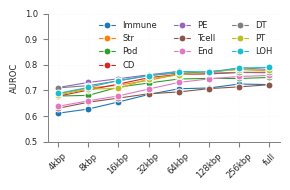

In [115]:
fig, ax = plt.subplots(figsize=FIGSIZE)

sns.lineplot(
    data=df_melted, x='Model', y='AUROC', hue='Type',
    marker='o', markersize=MARKERSIZE, linewidth=LINEWIDTH,
    palette=PALETTE, ax=ax, alpha=ALPHA
)

ax.set_xlabel('')

ax.set_ylabel('AUROC', fontsize=LABEL_FONTSIZE)
ax.set_ylim(0.5, 1.0)

plt.xticks(rotation=45)
#plt.yticks([0.6, 0.65, 0.7, 0.75, 0.8, 0.85])
plt.legend(title='', title_fontsize=LEGEND_FONTSIZE, fontsize=LEGEND_FONTSIZE,
           frameon=False, shadow=True, loc='upper right', ncol=3)

ax.spines['left'].set_linewidth(SPINE_WIDTH)
ax.spines['left'].set_color(SPINE_COLOR)
ax.spines['bottom'].set_linewidth(SPINE_WIDTH)
ax.spines['bottom'].set_color(SPINE_COLOR)

ax.tick_params(axis='both', which='major', labelsize=TICK_FONTSIZE,
               bottom=True, left=True, top=False, right=False, color=TICK_COLOR)

ax.grid(True, alpha=GRID_ALPHA, linestyle=GRID_LINESTYLE, linewidth=GRID_LINEWIDTH)

sns.despine(top=True, right=True, left=False, bottom=False)

plt.tight_layout()
plt.savefig('main_paper/fig5e_new.pdf', bbox_inches='tight')
plt.show()

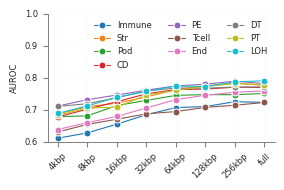

In [105]:
fig, ax = plt.subplots(figsize=FIGSIZE)

sns.lineplot(
    data=df_melted, x='Model', y='AUROC', hue='Type',
    marker='o', markersize=MARKERSIZE, linewidth=LINEWIDTH,
    palette=PALETTE, ax=ax, alpha=ALPHA
)

ax.set_xlabel('')

ax.set_ylabel('AUROC', fontsize=LABEL_FONTSIZE)
ax.set_ylim(0.6, 1.0)

plt.xticks(rotation=45)
#plt.yticks([0.6, 0.65, 0.7, 0.75, 0.8, 0.85])
plt.legend(title='', title_fontsize=LEGEND_FONTSIZE, fontsize=LEGEND_FONTSIZE,
           frameon=False, shadow=True, loc='upper right', ncol=3)

ax.spines['left'].set_linewidth(SPINE_WIDTH)
ax.spines['left'].set_color(SPINE_COLOR)
ax.spines['bottom'].set_linewidth(SPINE_WIDTH)
ax.spines['bottom'].set_color(SPINE_COLOR)

ax.tick_params(axis='both', which='major', labelsize=TICK_FONTSIZE,
               bottom=True, left=True, top=False, right=False, color=TICK_COLOR)

ax.grid(True, alpha=GRID_ALPHA, linestyle=GRID_LINESTYLE, linewidth=GRID_LINEWIDTH)

sns.despine(top=True, right=True, left=False, bottom=False)

plt.tight_layout()
#plt.savefig('main_paper/fig5e.pdf', bbox_inches='tight')
plt.show()

In [106]:
for ns_after, seq_label in ns_mapping.items():
    imm_val  = all_results['immune'][ns_after]['auprc'][0]
    str_val  = all_results['str'][ns_after]['auprc'][0]
    pod_val  = all_results['pod'][ns_after]['auprc'][0]
    cd_val = all_results['CD'][ns_after]['auprc'][0]
    pe_val  = all_results['PE'][ns_after]['auprc'][0]
    tcell_val  = all_results['tcell'][ns_after]['auprc'][0]
    end_val = all_results['end'][ns_after]['auprc'][0]
    dt_val  = all_results['dt'][ns_after]['auprc'][0]
    pt_val  = all_results['pt'][ns_after]['auprc'][0]
    loh_val = all_results['loh'][ns_after]['auprc'][0]

    data[seq_label] = [float(imm_val), float(str_val), float(pod_val), float(cd_val),float(pe_val), float(tcell_val), float(end_val),float(dt_val), float(pt_val), float(loh_val)]

    
    

# Create dataframe
df = pd.DataFrame(data, index=['Immune','Str', 'Pod', 'CD', 'PE', 'Tcell', 'End',  'DT', 'PT', 'LOH']).T
df.index.name = 'Model'

# Melt for plotting
df_melted = df.reset_index().melt(
    id_vars='Model',
    var_name='Type',
    value_name='AUPRC'
)


PALETTE = plt.cm.tab10.colors

# Melt for plotting
df_melted = df.reset_index().melt(
    id_vars='Model',
    var_name='Type',
    value_name='AUPRC'
)

df_melted['Model'] = pd.Categorical(
    df_melted['Model'],
    categories=SEQUENCE_ORDER,
    ordered=True
)

PALETTE_FULL = plt.cm.tab10.colors



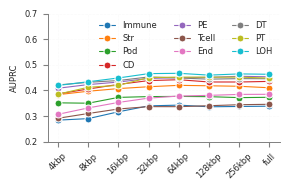

In [107]:
fig, ax = plt.subplots(figsize=FIGSIZE)
sns.lineplot(
    data=df_melted, x='Model', y='AUPRC', hue='Type',
    marker='o', markersize=MARKERSIZE, linewidth=LINEWIDTH,
    palette=PALETTE_FULL, ax=ax, alpha=ALPHA
)

ax.set_xlabel('')

ax.set_ylabel('AUPRC', fontsize=LABEL_FONTSIZE)
ax.set_ylim(0.2, 0.7)

plt.xticks(rotation=45)
#plt.yticks([0.6, 0.65, 0.7, 0.75, 0.8, 0.85])
plt.legend(title='', title_fontsize=LEGEND_FONTSIZE, fontsize=LEGEND_FONTSIZE,
           frameon=False, shadow=True, loc='upper right', ncol=3)

ax.spines['left'].set_linewidth(SPINE_WIDTH)
ax.spines['left'].set_color(SPINE_COLOR)
ax.spines['bottom'].set_linewidth(SPINE_WIDTH)
ax.spines['bottom'].set_color(SPINE_COLOR)

ax.tick_params(axis='both', which='major', labelsize=TICK_FONTSIZE,
               bottom=True, left=True, top=False, right=False, color=TICK_COLOR)

ax.grid(True, alpha=GRID_ALPHA, linestyle=GRID_LINESTYLE, linewidth=GRID_LINEWIDTH)

sns.despine(top=True, right=True, left=False, bottom=False)

plt.tight_layout()
plt.savefig('./fig5f.pdf', bbox_inches='tight')
plt.show()